# Spotify Top 10 Songs – Classification Notebook

In [4]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

sns.set(style="whitegrid")
%matplotlib inline


ModuleNotFoundError: No module named 'pandas'

## Load Dataset

In [3]:

df = pd.read_csv("top10s.csv", encoding="latin1")
df.head()


NameError: name 'pd' is not defined

## Exploration

In [ ]:

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 603 entries, 0 to 602
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  603 non-null    int64 
 1   title       603 non-null    object
 2   artist      603 non-null    object
 3   top genre   603 non-null    object
 4   year        603 non-null    int64 
 5   bpm         603 non-null    int64 
 6   nrgy        603 non-null    int64 
 7   dnce        603 non-null    int64 
 8   dB          603 non-null    int64 
 9   live        603 non-null    int64 
 10  val         603 non-null    int64 
 11  dur         603 non-null    int64 
 12  acous       603 non-null    int64 
 13  spch        603 non-null    int64 
 14  pop         603 non-null    int64 
dtypes: int64(12), object(3)
memory usage: 70.8+ KB


In [ ]:

df.describe()



,Unnamed: 0,year,bpm,nrgy,dnce,dB,live,val,dur,acous,spch,pop
count,603.000000,603.000000,603.000000,603.000000,603.000000,603.000000,603.000000,603.000000,603.000000,603.000000,603.000000,603.000000
mean,302.000000,2014.592040,118.545605,70.504146,64.379768,-5.578773,17.774461,52.225539,224.674959,14.326700,8.358209,66.520730
std,174.215384,2.607057,24.795358,16.310664,13.378718,2.798020,13.102543,22.513020,34.130059,20.766165,7.483162,14.517746
min,1.000000,2010.000000,0.000000,0.000000,0.000000,-60.000000,0.000000,0.000000,134.000000,0.000000,0.000000,0.000000
25%,151.500000,2013.000000,100.000000,61.000000,57.000000,-6.000000,9.000000,35.000000,202.000000,2.000000,4.000000,60.000000
50%,302.000000,2015.000000,120.000000,74.000000,66.000000,-5.000000,12.000000,52.000000,221.000000,6.000000,5.000000,69.000000
75%,452.500000,2017.000000,129.000000,82.000000,73.000000,-4.000000,24.000000,69.000000,239.500000,17.000000,9.000000,76.000000
max,603.000000,2019.000000,206.000000,98.000000,97.000000,-2.000000,74.000000,98.000000,424.000000,99.000000,48.000000,99.000000


## Cleaning

In [ ]:

if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])
df = df.rename(columns={"top genre":"top_genre", "dB":"db"})
df.head()


,title,artist,top_genre,year,bpm,nrgy,dnce,db,live,val,dur,acous,spch,pop
0,"Hey, Soul Sister",Train,neo mellow,2010,97,89,67,-4,8,80,217,19,4,83
1,Love The Way You Lie,Eminem,detroit hip hop,2010,87,93,75,-5,52,64,263,24,23,82
2,TiK ToK,Kesha,dance pop,2010,120,84,76,-3,29,71,200,10,14,80
3,Bad Romance,Lady Gaga,dance pop,2010,119,92,70,-4,8,71,295,0,4,79
4,Just the Way You Are,Bruno Mars,pop,2010,109,84,64,-5,9,43,221,2,4,78


## EDA

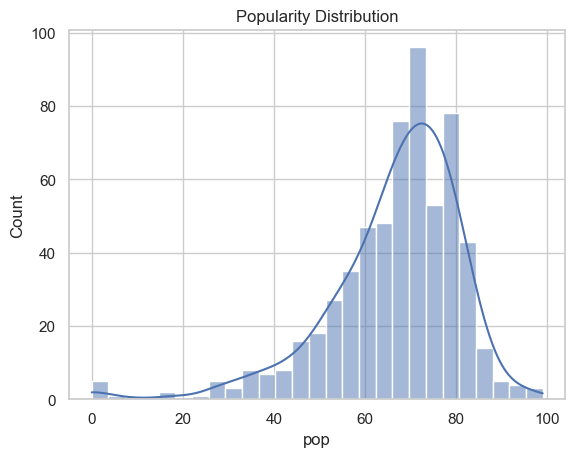

In [ ]:

sns.histplot(df["pop"], kde=True)
plt.title("Popularity Distribution")
plt.show()


## Feature Engineering

In [ ]:

median_pop = df["pop"].median()
df["popularity_level"] = np.where(df["pop"] >= median_pop, "High", "Low")
df[["title","artist","pop","popularity_level"]].head()


,title,artist,pop,popularity_level
0,"Hey, Soul Sister",Train,83,High
1,Love The Way You Lie,Eminem,82,High
2,TiK ToK,Kesha,80,High
3,Bad Romance,Lady Gaga,79,High
4,Just the Way You Are,Bruno Mars,78,High


In [ ]:

df_encoded = pd.get_dummies(df, columns=["top_genre"], drop_first=True)
df_encoded.head()


,title,artist,year,bpm,nrgy,dnce,db,live,val,dur,...,top_genre_house,top_genre_indie pop,top_genre_irish singer-songwriter,top_genre_latin,top_genre_metropopolis,top_genre_moroccan pop,top_genre_neo mellow,top_genre_permanent wave,top_genre_pop,top_genre_tropical house
0,"Hey, Soul Sister",Train,2010,97,89,67,-4,8,80,217,...,False,False,False,False,False,False,True,False,False,False
1,Love The Way You Lie,Eminem,2010,87,93,75,-5,52,64,263,...,False,False,False,False,False,False,False,False,False,False
2,TiK ToK,Kesha,2010,120,84,76,-3,29,71,200,...,False,False,False,False,False,False,False,False,False,False
3,Bad Romance,Lady Gaga,2010,119,92,70,-4,8,71,295,...,False,False,False,False,False,False,False,False,False,False
4,Just the Way You Are,Bruno Mars,2010,109,84,64,-5,9,43,221,...,False,False,False,False,False,False,False,False,True,False


## Train/Test Split

In [ ]:

feature_cols = [c for c in df_encoded.columns if c not in ["title","artist","popularity_level"]]
X = df_encoded[feature_cols]
y = df_encoded["popularity_level"]

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=42,stratify=y)

X_train.shape, X_test.shape


((422, 60), (181, 60))

## Scaling

In [ ]:

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## Models

In [ ]:

log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_scaled, y_train)
pred_lr = log_reg.predict(X_test_scaled)
print("LogReg Accuracy:", accuracy_score(y_test, pred_lr))
print(classification_report(y_test, pred_lr))


LogReg Accuracy: 0.9558011049723757
              precision    recall  f1-score   support

        High       0.95      0.97      0.96        95
         Low       0.96      0.94      0.95        86

    accuracy                           0.96       181
   macro avg       0.96      0.96      0.96       181
weighted avg       0.96      0.96      0.96       181



In [ ]:

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
pred_dt = dt.predict(X_test)
print("Decision Tree Accuracy:", accuracy_score(y_test, pred_dt))
print(classification_report(y_test, pred_dt))


Decision Tree Accuracy: 1.0
              precision    recall  f1-score   support

        High       1.00      1.00      1.00        95
         Low       1.00      1.00      1.00        86

    accuracy                           1.00       181
   macro avg       1.00      1.00      1.00       181
weighted avg       1.00      1.00      1.00       181



In [ ]:

rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, pred_rf))
print(classification_report(y_test, pred_rf))


Random Forest Accuracy: 1.0
              precision    recall  f1-score   support

        High       1.00      1.00      1.00        95
         Low       1.00      1.00      1.00        86

    accuracy                           1.00       181
   macro avg       1.00      1.00      1.00       181
weighted avg       1.00      1.00      1.00       181



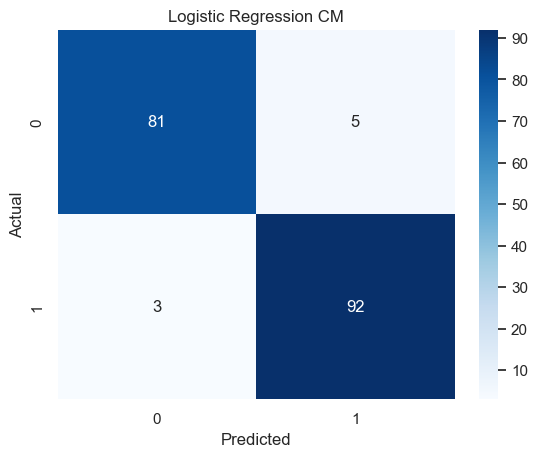

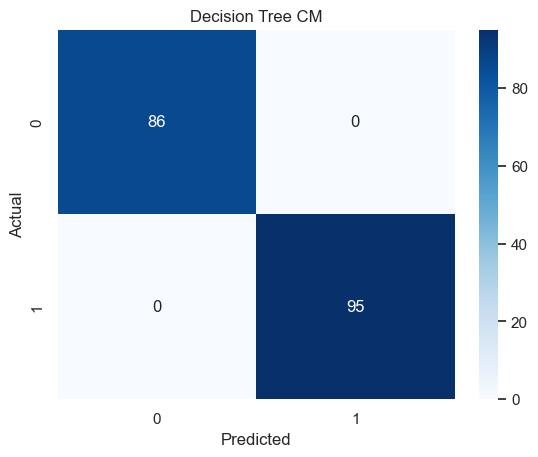

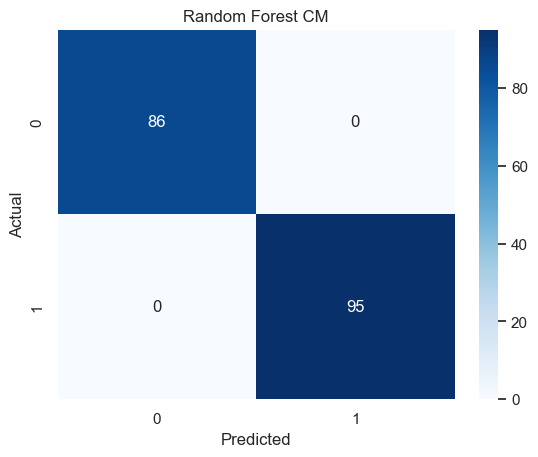

In [ ]:

def plot_cm(cm,title):
    sns.heatmap(cm,annot=True,fmt="d",cmap="Blues")
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

cm_lr = confusion_matrix(y_test, pred_lr, labels=["Low","High"])
cm_dt = confusion_matrix(y_test, pred_dt, labels=["Low","High"])
cm_rf = confusion_matrix(y_test, pred_rf, labels=["Low","High"])

plot_cm(cm_lr, "Logistic Regression CM")
plot_cm(cm_dt, "Decision Tree CM")
plot_cm(cm_rf, "Random Forest CM")


## Feature Importance

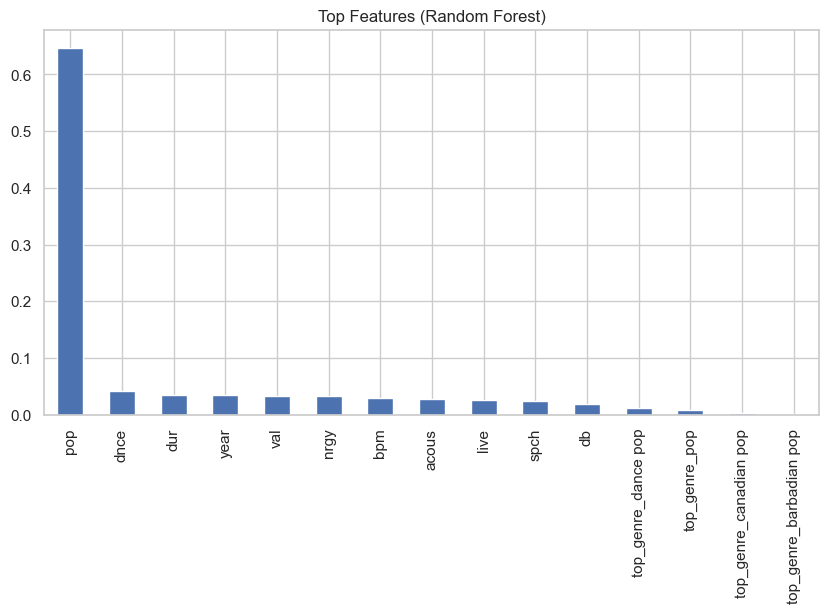

pop                        0.646466
dnce                       0.042125
dur                        0.035518
year                       0.034845
val                        0.033490
nrgy                       0.033196
bpm                        0.029505
acous                      0.027524
live                       0.026318
spch                       0.023624
db                         0.019666
top_genre_dance pop        0.011347
top_genre_pop              0.007707
top_genre_canadian pop     0.002358
top_genre_barbadian pop    0.002205
dtype: float64

In [ ]:

importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)
importances.head(15).plot(kind="bar", figsize=(10,5))
plt.title("Top Features (Random Forest)")
plt.show()

importances.head(15)


## Conclusion
Random Forest typically performs best.